# 🔌 Stazioni di Ricarica EV in Europa — Confronto Annuale per Paese

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import urllib.request
from PIL import Image
import io
from matplotlib.patches import Circle
import os
import seaborn as sns

# Carica i dati
df = pd.read_csv('../data/csv/stazioni_ricarica_europa.csv')
df.head()


COUNTRY_COLORS = {
    'Netherlands': '#E87722',
    'France':      '#003189',
    'Germany':     '#000000',
    'United Kingdom': "#C810A6",
    'Italy':       '#009246',
    'Spain':       '#AA151B',
}


,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,Netherlands,Historical,EV charging points,EV,Publicly available slow,2024,charging points,180000,#NAME?
1,Netherlands,Historical,EV charging points,EV,Publicly available slow,2023,charging points,140000,#NAME?
2,France,Historical,EV charging points,EV,Publicly available slow,2024,charging points,120000,#NAME?
3,Germany,Historical,EV charging points,EV,Publicly available slow,2024,charging points,120000,#NAME?
4,Netherlands,Historical,EV charging points,EV,Publicly available slow,2022,charging points,120000,#NAME?


In [ ]:
# Aggregazione: totale punti di ricarica per paese e anno
df_agg = df.groupby(['region_country', 'year'])['value'].sum().reset_index()
df_agg.columns = ['Paese', 'Anno', 'Punti_Ricarica']

# Paesi disponibili
paesi = df_agg['Paese'].unique()

Paesi: ['France' 'Germany' 'Italy' 'Netherlands' 'Spain' 'United Kingdom']


## 📈 Grafico a linee — Evoluzione anno per anno

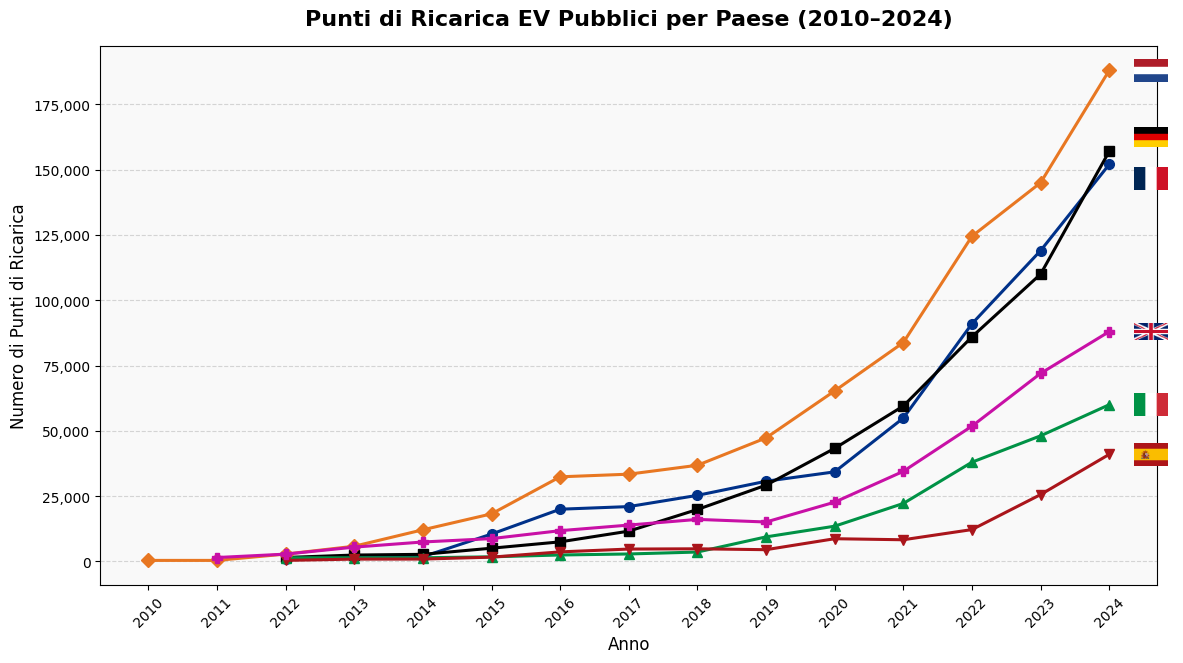

In [ ]:
# Codici ISO per le flag
flag_codes = {
    'Netherlands': 'nl',
    'France':      'fr',
    'Germany':     'de',
    'United Kingdom': 'gb',
    'Italy':       'it',
    'Spain':       'es',
}

def get_flag(country_code, size=30):
    url = f'https://flagcdn.com/w40/{country_code}.png'
    with urllib.request.urlopen(url) as r:
        img = Image.open(io.BytesIO(r.read())).convert('RGBA')
    return img

fig, ax = plt.subplots(figsize=(14, 7))

markers = ['o', 's', '^', 'D', 'v', 'P', '*']

for i, paese in enumerate(sorted(paesi)):
    d = df_agg[df_agg['Paese'] == paese].sort_values('Anno')
    colore = COUNTRY_COLORS.get(paese, f'C{i}')
    ax.plot(
        d['Anno'], d['Punti_Ricarica'],
        marker=markers[i % len(markers)],
        linewidth=2.2, markersize=7,
        color=colore, label=paese
    )
    
    # Aggiunge bandiera all'ultimo punto
    if not d.empty:
        ultimo_anno = d['Anno'].iloc[-1]
        ultimo_valore = d['Punti_Ricarica'].iloc[-1]
        flag_offset_y = {
            'Netherlands': 0,
            'France':      -10,
            'Germany':     10, 
            'United Kingdom': 0,
            'Italy':       0,
            'Spain':       0,
        }
        code = flag_codes.get(paese)
        if code:
            try:
                flag_img = get_flag(code)
                imagebox = OffsetImage(flag_img, zoom=0.6)
                imagebox.image.axes = ax
                ab = AnnotationBbox(
                    imagebox,
                    (ultimo_anno, ultimo_valore),
                    xybox=(30, flag_offset_y.get(paese, 0)),  
                    xycoords='data',
                    boxcoords='offset points',
                    frameon=False,   # nessun bordo
                )
                ax.add_artist(ab)
            except:
                pass  # se non riesce a scaricare, salta


ax.set_title('Punti di Ricarica EV Pubblici per Paese (2010–2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Numero di Punti di Ricarica', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')

# Margine a destra per le bandiere
plt.subplots_adjust(right=0.88)
plt.show()

## 📊 Grafico a barre raggruppate — Confronto diretto per anno (dal 2018)

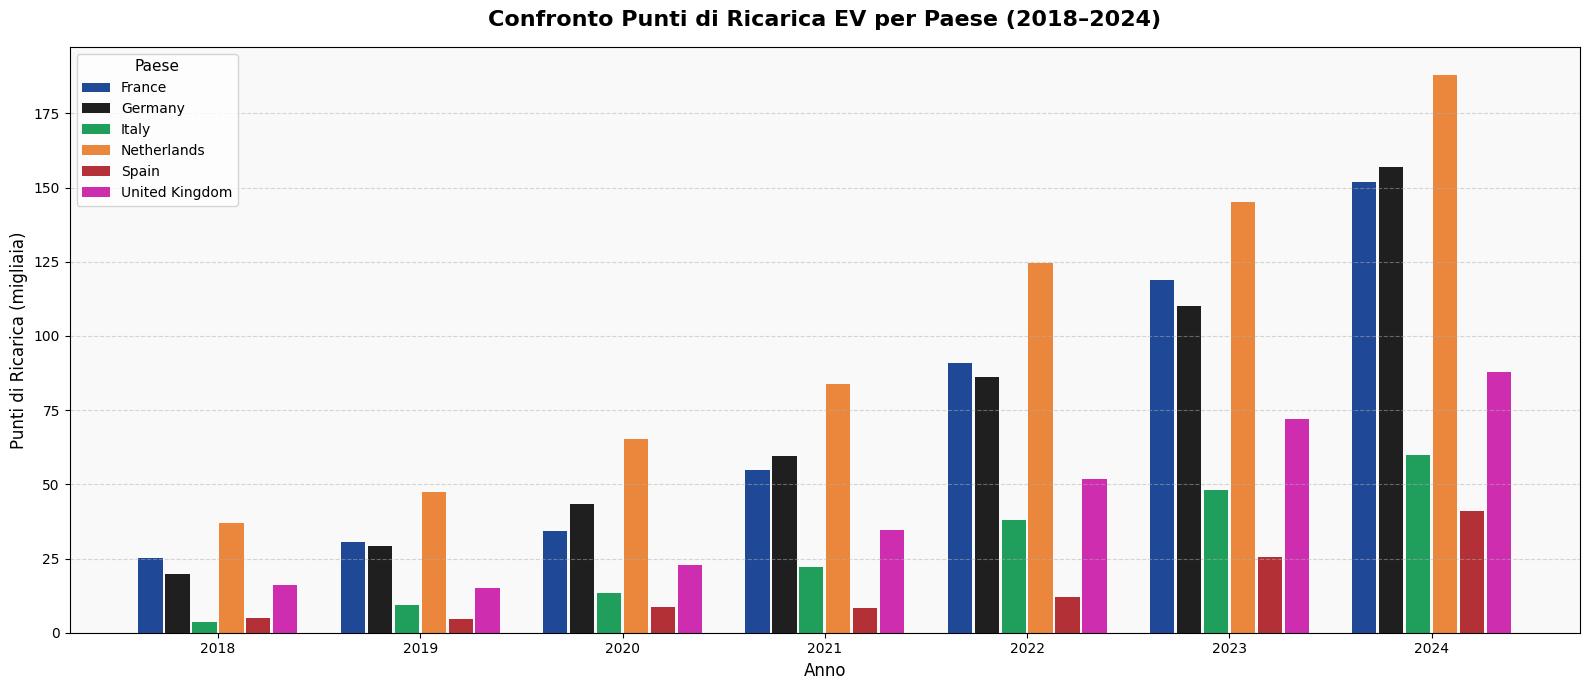

In [ ]:
anni_sel = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
df_bar = df_agg[df_agg['Anno'].isin(anni_sel)]
pivot = df_bar.pivot(index='Anno', columns='Paese', values='Punti_Ricarica').fillna(0)

fig, ax = plt.subplots(figsize=(16, 7))
n_paesi = len(pivot.columns)
x = np.arange(len(pivot.index))
larghezza = 0.8 / n_paesi

for i, paese in enumerate(pivot.columns):
    offset = (i - n_paesi / 2 + 0.5) * larghezza
    colore = COUNTRY_COLORS.get(paese, f'C{i}')
    bars = ax.bar(x + offset, pivot[paese] / 1000, larghezza * 0.9,
                  label=paese, color=colore, alpha=0.88)

ax.set_title('Confronto Punti di Ricarica EV per Paese (2018–2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Punti di Ricarica (migliaia)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend(title='Paese', fontsize=10, title_fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## 🔥 Heatmap — Intensità per Paese e Anno

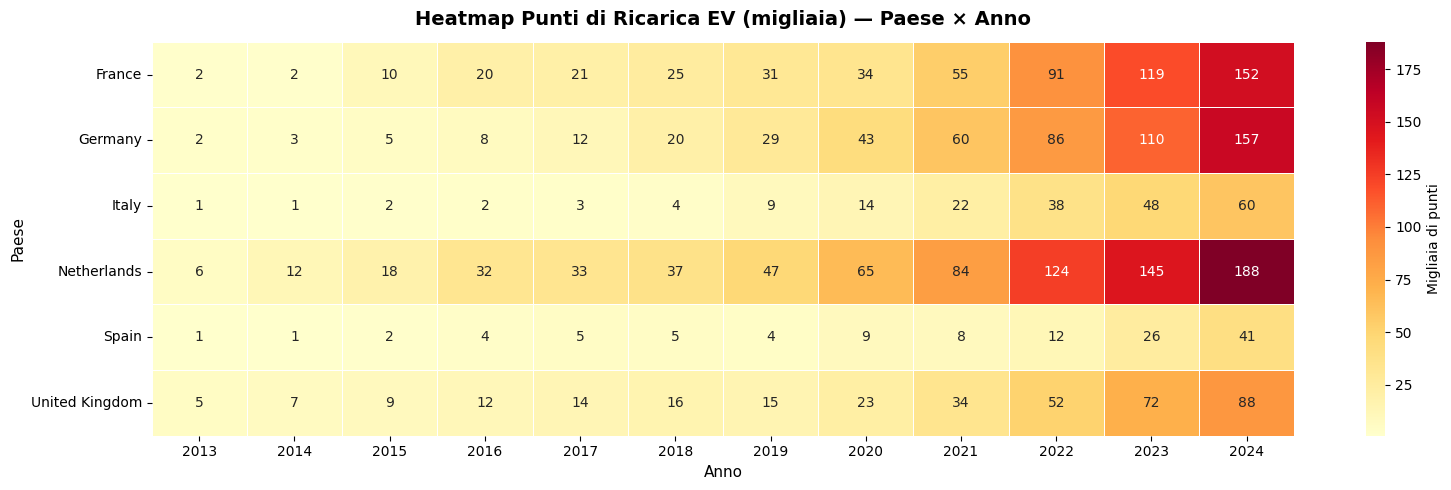

In [ ]:
pivot_full = df_agg.pivot(index='Paese', columns='Anno', values='Punti_Ricarica').fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_full / 1000,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Migliaia di punti'}
)
ax.set_title('Heatmap Punti di Ricarica EV (migliaia) — Paese × Anno', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Anno', fontsize=11)
ax.set_ylabel('Paese', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# COUNTRY_COLORS e posizioni
COUNTRY_COLORS_immagine = {
    'Netherlands': '#E87722', 'France': '#003189', 'Germany': "#DECB00",
    'United Kingdom': "#C810A6", 'Italy': '#009246', 'Spain': '#AA151B'
}
country_positions = {
    'Netherlands': (0, 56),
    'Germany': (11, 57), 'France': (-10, 48), 'Italy': (12, 45),
    'United Kingdom': (-12, 59), 'Spain': (0, 45)
}

# Crea cartella
os.makedirs('frames_ev', exist_ok=True)

# SALVA 10 IMMAGINI
for anno in range(2012, 2025):
    fig, ax = plt.subplots(figsize=(12, 8), facecolor='black')
    ax.set_xlim(-18, 18)
    ax.set_ylim(40, 68)
    ax.set_aspect('equal')
    ax.axis('off')
    
    dati_anno = df_agg[df_agg['Anno'] == anno]
    
    for _, row in dati_anno.iterrows():
        paese = row['Paese'].title() 
        valore = row['Punti_Ricarica']
        if pd.isna(valore) or valore <= 0:
            continue
            
        x, y = country_positions.get(paese, (0, 50))
        raggio = np.sqrt(valore / 1000) * 0.65
        
        colore = COUNTRY_COLORS_immagine.get(paese, '#FFFFFF')
        circle = Circle((x, y), raggio, color=colore, alpha=0.85, ec='white', lw=2)
        ax.add_patch(circle)
        
        ax.text(x, y + raggio*0.3, f"{paese}\n{int(valore):,}",
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')
    
    ax.text(0, 66, f'PUNTI RICARICA EV EUROPA — {anno}', 
            ha='center', fontsize=24, fontweight='bold', color='black',
            bbox=dict(boxstyle="round,pad=1", facecolor="#B8B6B6", alpha=0.8))
    
    plt.savefig(f'frames_ev/anno_{anno:04d}.png', dpi=150, bbox_inches='tight', 
                facecolor="#FFFFFF", pad_inches=0.1)
    plt.close(fig)
